# Step 2: Tokenization & STADM (F2)

Abraham Tedla (wqp7qy@virginia.edu)  
DS 5001  
April 2026

Tokenize the MLCF corpus into TOKEN and VOCAB tables conforming to the Standard Text Analytic Data Model.

# Set Up

In [59]:
import pandas as pd
import numpy as np
import re
import os

np.random.seed(42)

In [60]:
import seaborn as sns
sns.set()
%matplotlib inline

In [61]:
output_dir = 'output'

OHCO = ['book_id', 'chapter', 'para_num', 'sent_num']
BOOKS = OHCO[:1]
CHAPS = OHCO[:2]
PARAS = OHCO[:3]
SENTS = OHCO[:4]

# Load F1 Data

In [62]:
CORPUS = pd.read_csv(os.path.join(output_dir, 'CORPUS_F1.csv')).set_index(OHCO).sort_index()
LIBRARY = pd.read_csv(os.path.join(output_dir, 'LIBRARY.csv')).set_index('book_id').sort_index()

In [63]:
CORPUS.head()

sent_str
book_id chapter para_num sent_num                                                   
35      1       0        0                                              Introduction
                1        0         The Time Traveller (for so it will be convenie...
                         1         His pale grey eyes shone and twinkled, and his...
                         2         The fire burnt brightly, and the soft radiance...
                         3         Our chairs, being his patents, embraced and ca...

In [64]:
LIBRARY

,title,author,genre,source_url,format,provenance,char_count
book_id,,,,,,,
35,The Time Machine,"Wells, H. G.",SciFi,https://www.gutenberg.org/ebooks/35,plaintext (UTF-8),Project Gutenberg,179690
36,The War of the Worlds,"Wells, H. G.",SciFi,https://www.gutenberg.org/ebooks/36,plaintext (UTF-8),Project Gutenberg,337423
42,Dr. Jekyll and Mr. Hyde,"Stevenson, Robert Louis",Gothic,https://www.gutenberg.org/ebooks/42,plaintext (UTF-8),Project Gutenberg,139248
62,A Princess of Mars,"Burroughs, Edgar Rice",SciFi,https://www.gutenberg.org/ebooks/62,plaintext (UTF-8),Project Gutenberg,371058
84,Frankenstein,"Shelley, Mary",Gothic,https://www.gutenberg.org/ebooks/84,plaintext (UTF-8),Project Gutenberg,419336
139,The Lost World,"Doyle, Arthur Conan",SciFi,https://www.gutenberg.org/ebooks/139,plaintext (UTF-8),Project Gutenberg,424011
159,The Island of Doctor Moreau,"Wells, H. G.",SciFi,https://www.gutenberg.org/ebooks/159,plaintext (UTF-8),Project Gutenberg,241161
164,Twenty Thousand Leagues Under the Sea,"Verne, Jules",SciFi,https://www.gutenberg.org/ebooks/164,plaintext (UTF-8),Project Gutenberg,597840
174,The Picture of Dorian Gray,"Wilde, Oscar",Gothic,https://www.gutenberg.org/ebooks/174,plaintext (UTF-8),Project Gutenberg,429312


# Tokenize Sentences

Split each sentence into word tokens. Keep only alphabetic tokens and lowercase them to get `term_str`.

In [65]:
import nltk
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('averaged_perceptron_tagger', quiet=True)
nltk.download('averaged_perceptron_tagger_eng', quiet=True)
from nltk.tokenize import word_tokenize

In [66]:
token_rows = []

for idx, row in CORPUS.iterrows():
    sent = str(row['sent_str'])
    words = word_tokenize(sent)
    
    token_num = 0
    for w in words:
        if w.isalpha():  # keep only alphabetic tokens
            token_rows.append({
                'book_id': idx[0],
                'chapter': idx[1],
                'para_num': idx[2],
                'sent_num': idx[3],
                'token_num': token_num,
                'token_str': w,
                'term_str': w.lower(),
            })
            token_num += 1

print(f'Total tokens: {len(token_rows):,}')

Total tokens: 871,168


In [67]:
TOKEN = pd.DataFrame(token_rows)
TOKEN = TOKEN.set_index(OHCO + ['token_num']).sort_index()
TOKEN.head(10)

token_str      term_str
book_id chapter para_num sent_num token_num                            
35      1       0        0        0          Introduction  introduction
                1        0        0                   The           the
                                  1                  Time          time
                                  2             Traveller     traveller
                                  3                   for           for
                                  4                    so            so
                                  5                    it            it
                                  6                  will          will
                                  7                    be            be
                                  8            convenient    convenient

In [68]:
TOKEN.sample(10)

token_str  term_str
book_id chapter para_num sent_num token_num                    
159     21      50       1        25         thickets  thickets
696     3       8        0        2                to        to
                105      4        19               to        to
345     26      2        0        21          against   against
164     22      26       0        9               him       him
62      18      26       1        34               in        in
345     2       39       6        47            sweep     sweep
174     9       74       0        18              the       the
62      21      29       2        19          propels   propels
345     24      57       1        3                 s         s

## POS Tagging

In [69]:
# POS tag in batches by sentence for accuracy
# We'll group tokens back into sentences, tag, then assign

pos_tags = []
for (book_id, chapter, para_num, sent_num), group in TOKEN.groupby(level=SENTS):
    words = group['token_str'].tolist()
    tagged = nltk.pos_tag(words)
    for _, tag in tagged:
        pos_tags.append(tag)

TOKEN['pos'] = pos_tags
print('POS tagging complete')

POS tagging complete


In [70]:
TOKEN.head(10)

token_str      term_str  pos
book_id chapter para_num sent_num token_num                                 
35      1       0        0        0          Introduction  introduction   NN
                1        0        0                   The           the   DT
                                  1                  Time          time  NNP
                                  2             Traveller     traveller  NNP
                                  3                   for           for   IN
                                  4                    so            so   IN
                                  5                    it            it  PRP
                                  6                  will          will   MD
                                  7                    be            be   VB
                                  8            convenient    convenient   JJ

## Tokens per Book

In [71]:
TOKEN.groupby('book_id').size()

book_id
35      32459
36      60064
42      25465
62      65882
84      74896
139     75017
159     43034
164    102890
174     79056
345    159926
696     34985
768    117494
dtype: int64

<Axes: ylabel='book_id'>

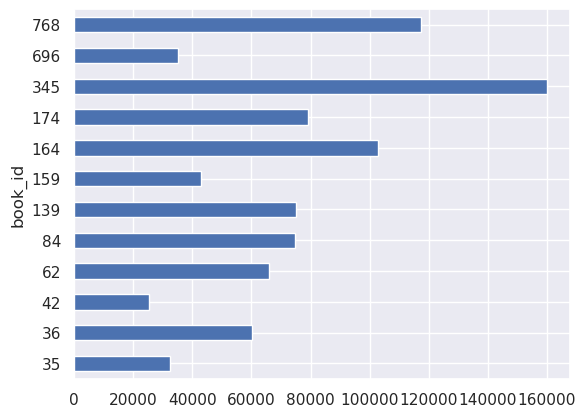

In [72]:
TOKEN.groupby('book_id').size().plot.barh()

## POS Distribution

In [73]:
TOKEN['pos'].value_counts().head(15)

pos
NN      123083
IN      110234
DT       90502
PRP      82847
VBD      63192
JJ       54804
RB       47998
CC       38337
VB       34738
NNS      33090
PRP$     27396
NNP      26902
TO       22589
VBN      22198
VBP      17610
Name: count, dtype: int64

<Axes: ylabel='pos'>

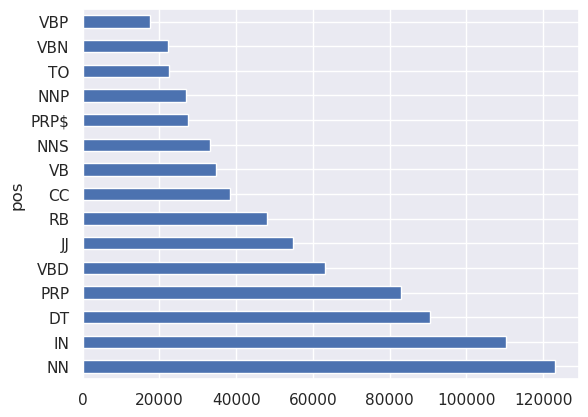

In [74]:
TOKEN['pos'].value_counts().head(15).plot.barh()

# Build VOCAB Table

One row per unique term with count (`n`) and document frequency (`df`).

In [75]:
# Term frequency (total count across corpus)
term_counts = TOKEN['term_str'].value_counts().rename('n')

# Document frequency (number of books the term appears in)
doc_freq = TOKEN.reset_index().groupby('term_str')['book_id'].nunique().rename('df')

VOCAB = pd.DataFrame({'n': term_counts, 'df': doc_freq})
VOCAB.index.name = 'term_str'
VOCAB = VOCAB.sort_values('n', ascending=False)

In [76]:
print(f'Unique terms: {len(VOCAB):,}')
VOCAB.head(20)

Unique terms: 25,122


,n,df
term_str,,
the,51573,12
and,29951,12
of,26564,12
i,24740,12
to,22596,12
a,18147,12
in,13074,12
that,11537,12
was,11170,12


In [77]:
VOCAB.tail(20)

,n,df
term_str,,
reproof,1,1
repressed,1,1
galled,1,1
galleon,1,1
repository,1,1
gambier,1,1
gama,1,1
reporters,1,1
galvanism,1,1


In [78]:
VOCAB['n'].describe()

count    25122.000000
mean        34.677494
std        543.856847
min          1.000000
25%          1.000000
50%          3.000000
75%          9.000000
max      51573.000000
Name: n, dtype: float64

In [79]:
# Most common POS for each term
max_pos = TOKEN.groupby('term_str')['pos'].agg(lambda x: x.value_counts().index[0]).rename('max_pos')
VOCAB = VOCAB.join(max_pos)

In [80]:
VOCAB.head(20)

,n,df,max_pos
term_str,,,
the,51573,12,DT
and,29951,12,CC
of,26564,12,IN
i,24740,12,PRP
to,22596,12,TO
a,18147,12,DT
in,13074,12,IN
that,11537,12,IN
was,11170,12,VBD


## Top Terms

<Axes: ylabel='term_str'>

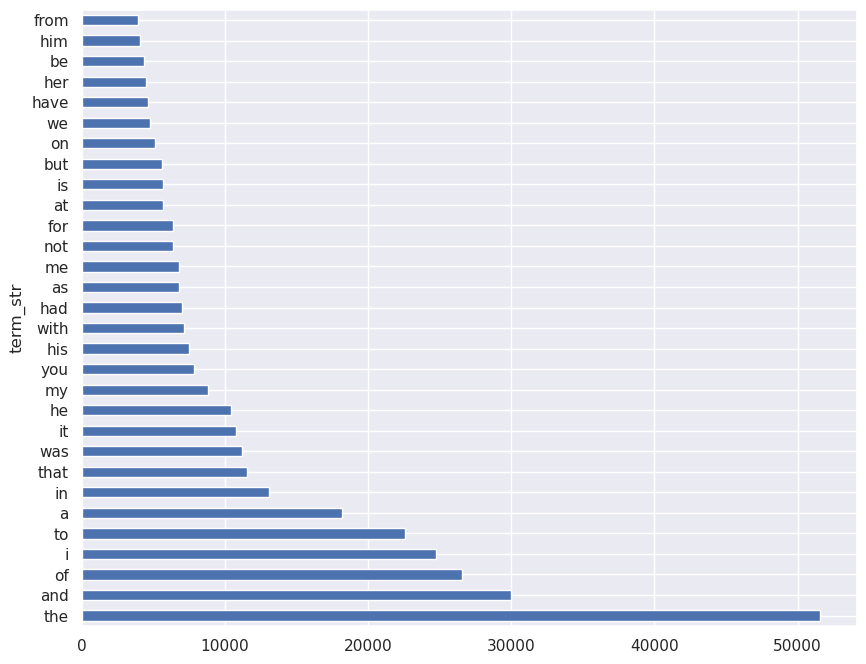

In [81]:
VOCAB.head(30)['n'].plot.barh(figsize=(10, 8))

## Vocab Size by Book

In [82]:
TOKEN.reset_index().groupby('book_id')['term_str'].nunique()

book_id
35     4505
36     6610
42     3832
62     6345
84     6907
139    7517
159    5083
164    8461
174    6568
345    8980
696    4114
768    9053
Name: term_str, dtype: int64

# Add term_id to TOKEN

Map each term to a numeric ID for downstream vector operations.

In [83]:
VOCAB = VOCAB.reset_index()
VOCAB['term_id'] = range(len(VOCAB))
VOCAB = VOCAB.set_index('term_str')

In [84]:
TOKEN = TOKEN.join(VOCAB[['term_id']], on='term_str')
TOKEN.head(10)

token_str      term_str  pos  \
book_id chapter para_num sent_num token_num                                    
35      1       0        0        0          Introduction  introduction   NN   
                1        0        0                   The           the   DT   
                                  1                  Time          time  NNP   
                                  2             Traveller     traveller  NNP   
                                  3                   for           for   IN   
                                  4                    so            so   IN   
                                  5                    it            it  PRP   
                                  6                  will          will   MD   
                                  7                    be            be   VB   
                                  8            convenient    convenient   JJ   

                                             term_id  
book_id chapter para_num sent_num token_num           
35      1       0        0        0             4713  
                1        0        0                0  
                                  1               71  
                                  2             1169  
                                  3               19  
                                  4               36  
                                  5                9  
                                  6               57  
                                  7               27  
                                  8             3523

# Save Outputs

In [85]:
TOKEN.to_csv(os.path.join(output_dir, 'TOKEN.csv'))
print(f'Saved TOKEN.csv ({len(TOKEN):,} rows)')

Saved TOKEN.csv (871,168 rows)


In [86]:
VOCAB.to_csv(os.path.join(output_dir, 'VOCAB.csv'))
print(f'Saved VOCAB.csv ({len(VOCAB):,} rows)')

Saved VOCAB.csv (25,122 rows)


# Summary

- Tokenized ~49K sentences into word tokens (alphabetic only, lowercased).
- Added POS tags via NLTK.
- Built TOKEN table with OHCO index `(book_id, chapter, para_num, sent_num, token_num)`.
- Built VOCAB table with `n` (count), `df` (doc frequency), `max_pos`, and `term_id`.
- Saved `TOKEN.csv` and `VOCAB.csv`.

**Next:** Step 3 — NLP Annotation (F3): stopwords, stems, lemmas, sentiment.